In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from Bio.Seq import Seq
import matplotlib.pyplot as plt
from abnumber import Chain

# NetAM imports
from netam import pretrained
from netam.framework import Crepe
from netam.models import IndepRSCNNModel
from netam.molevol import neutral_codon_probs_of_seq
from netam.sequences import CODONS, CODON_TO_INDEX, AMBIGUOUS_CODON_IDX

# Evo Module imports
from evo.antibody import KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ
from evo.sequence import get_mutant
from evo.dms import get_site_by_site_consensus
from evo.dataset import ComplexCherriesDataset
from evo.tokenization import CodonVocab
from evo.tensor import collate_list_of_dicts, collate_tensors

# Peint imports
from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.codon import CodonDataset
from peint.models.modules.peint_module import PEINTModule
from peint.models.nets.peint import PEINT, ESMCodonEncoder, PEINTGenerator

tqdm.pandas()

# Scaling Factor relating PEINT trained branch lengths to standard phylogenetic branch lengths
BL_CORRECTION = 42.517871366

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Load PEINT Model from Checkpoint

In [ ]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/scratch/users/stephen.lu/projects/protevo/logs/train/runs/2025-10-20_02-46-17/checkpoints")
ckpt_path = ckpt_dir / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# create a fresh peint model with the same hyperparameters as the training run
vocab = CodonVocab.from_codons()
esm_encoder = ESMCodonEncoder.from_pretrained(
    codon_vocab=vocab,
    codon_embed_dim=384,
)
net = PEINT(
    enc_model=esm_encoder,
    evo_vocab=vocab,
    embed_dim=1024,
    num_heads=16,
    num_chains=2,
    num_encoder_layers=3,
    num_decoder_layers=3,
    max_len=1022,
    dropout_p=0.0,
    use_chain_embedding=True,
    use_attention_bias=True,
    causal_decoder=True,
)
module = PEINTModule.load_from_checkpoint(ckpt_path, net=net, map_location=device, strict=False)
module.net.in_embedding.codon_embedding.weight = module.net.enc_model.codon_embedding.weight
module = module.eval()

Using device: cuda


/scratch/users/aakarshv/venvs/peint_env/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:191: Found keys that are in the model state dict but not in the checkpoint: ['net.enc_model.codon_to_aa_mapping', 'net.in_embedding.codon_embedding.weight']


In [ ]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None, permute_chains=False):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = CodonDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        mask_prob=mask_prob,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        embed_x_per_chain=True,
        permute_method="reverse",
        permute_chain_order=permute_chains,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

        bls.append(ts.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks, vocab=vocab):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

def replace_with_codons(wt_nt_sequence: str, mut: str, offset: int = 0):
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = [k for k,v in codon_table.items() if v == new_aa]
    nt_pos = (pos - offset) * 3
    new_sequences = []
    for codon in codons:
        new_seq = wt_nt_sequence[:nt_pos] + codon + wt_nt_sequence[nt_pos+3:]
        new_sequences.append(new_seq)
    return new_sequences

def get_codons_from_mut(mut: str) -> List[str]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = [k for k,v in codon_table.items() if v == new_aa]
    return codons

def compute_edit_distance_of_codon_mut(wt_nucleotide_seq: str, aa_mut: str) -> List[int]:
    wt_aa, pos, new_aa = aa_mut[:1], int(aa_mut[1:-1]), aa_mut[-1:]
    codons = get_codons_from_mut(aa_mut)
    nt_pos = pos * 3
    wt_codon = wt_nucleotide_seq[nt_pos:nt_pos+3]
    edit_distances = [sum(c1 != c2 for c1, c2 in zip(wt_codon, codon)) for codon in codons]
    return edit_distances

def compute_codon_probs(codon_idxs: torch.Tensor, codon_probs: torch.Tensor) -> float:
    # codon_idxs is a 1d tensor of codon indices (seq_len,) and codon_probs is a 2d tensor of shape (seq_len, num_codons)
    return codon_probs[torch.arange(codon_idxs.size(0)), codon_idxs].sum().item()

def compute_mutant_codon_probs(wt_codon_idxs: torch.Tensor, mut: str, codon_probs: torch.Tensor) -> List[float]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = get_codons_from_mut(mut)
    mt_codon_idxs = [CODON_TO_INDEX[codon] for codon in codons]
    mt_codon_seq_probs = []
    for mt_codon_idx in mt_codon_idxs:
        mutant_codon_idxs = wt_codon_idxs.clone()
        mutant_codon_idxs[pos] = mt_codon_idx
        mutant_codon_prob = compute_codon_probs(mutant_codon_idxs, codon_probs)
        mt_codon_seq_probs.append(mutant_codon_prob )
    return mt_codon_seq_probs

# Load and preprocess Koenig DMS data

In [5]:
df = pd.read_csv("/scratch/users/aakarshv/peint_antibody/dms//Koenig2017_g6_er.csv")
df = df[['heavy', 'light', 'fitness']]

heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))

df_heavy = df[df['heavy_mut'] != '']
df_light = df[df['light_mut'] != '']
df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
df_light.rename(columns={'light_mut': 'mut'}, inplace=True)
df_heavy.set_index('mut', inplace=True)
df_light.set_index('mut', inplace=True)

heavy_mut_codes = df_heavy.index.values.tolist()
light_mut_codes = df_light.index.values.tolist()

print(df_heavy.shape, df_light.shape)
print(len(df_heavy) + len(df_light))

codon_table = CodonVocab.GENETIC_CODE
assert Seq(KOENIG_IGH_CON_SEQ).translate() == heavy_wt
assert Seq(KOENIG_IGK_CON_SEQ).translate() == light_wt

120 108 228
(2261, 4) (2014, 4)
4275


/tmp/ipykernel_173389/569456119.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
/tmp/ipykernel_173389/569456119.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_light.rename(columns={'light_mut': 'mut'}, inplace=True)


# Evaluate Peint on Koenig

In [6]:
LIGHT_CHAIN_BL = 5
HEAVY_CHAIN_BL = 5
hv_transitions = []
lt_transitions = []
hv_muts = []
lt_muts = []

for i, row in tqdm(df_heavy.iterrows()):
    hv_mut = row.name
    hv_nt_targets = replace_with_codons(KOENIG_IGH_CON_SEQ, hv_mut, offset=0)
    hv_muts.extend([hv_mut] * len(hv_nt_targets))
    t = HEAVY_CHAIN_BL
    hv_transitions.extend([f"{KOENIG_IGH_CON_SEQ}.{KOENIG_IGK_CON_SEQ} {hv_mt}.{KOENIG_IGK_CON_SEQ} {t}" for hv_mt in hv_nt_targets])

for i, row in tqdm(df_light.iterrows()):
    lt_mut = row.name
    lt_nt_targets = replace_with_codons(KOENIG_IGK_CON_SEQ, lt_mut, offset=0)
    lt_muts.extend([lt_mut] * len(lt_nt_targets))
    t = LIGHT_CHAIN_BL
    lt_transitions.extend([f"{KOENIG_IGH_CON_SEQ}.{KOENIG_IGK_CON_SEQ} {KOENIG_IGH_CON_SEQ}.{lt_mt} {t}" for lt_mt in lt_nt_targets])

hv_dataloader = dataloader_from_transitions(hv_transitions, batch_size=32, permute_chains=False)
hv_lls, _, hv_ppl = infer_log_likelihoods(hv_dataloader, module, n_batches=-1)

lt_dataloader = dataloader_from_transitions(lt_transitions, batch_size=32, permute_chains=False)
lt_lls, _, lt_ppl = infer_log_likelihoods(lt_dataloader, module, n_batches=-1)

2261it [00:00, 19855.66it/s]
2014it [00:00, 20519.16it/s]
Inference: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 190/190 [00:24<00:00,  7.75it/s]


In [7]:
# map the heavy and light chain log likelihoods and perplexities to the mutations in a dictionary
hv_ll_dict, lt_ll_dict = defaultdict(list), defaultdict(list)

for hv_mut, hv_ll in zip(hv_muts, hv_lls):
    hv_ll_dict[hv_mut].append(hv_ll)

for lt_mut, lt_ll in zip(lt_muts, lt_lls):
    lt_ll_dict[lt_mut].append(lt_ll)

# Neutral Mutation Correction (OPTIONAL)

In [8]:
crepe = pretrained.load("ThriftyHumV0.2-45")
multihit_model = pretrained.load_multihit("ThriftyHumV0.2-59-hc-tangshm", device="cpu")
print(crepe)
print(multihit_model)

Loading model ThriftyHumV0.2-45
Using cached models: /scratch/users/aakarshv/venvs/peint_env/lib/python3.10/site-packages/netam/_pretrained/thrifty-0.2.0.zip
Loading multihit model ThriftyHumV0.2-59-hc-tangshm
HitClassModel()


In [9]:
# Compute neutral codon substitution probabilities for the wildtype sequences
MULTIHIT = True
heavy_branch_length = 12.5/BL_CORRECTION
light_branch_length = 12.5/BL_CORRECTION

nt_rates, csp_logits = crepe([KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ])
csps = torch.softmax(csp_logits, dim=-1)

heavy_nt_rates, heavy_csps = nt_rates[0], csps[0]
light_nt_rates, light_csps = nt_rates[1], csps[1]
heavy_mask = torch.zeros_like(heavy_nt_rates, dtype=torch.bool)
light_mask = torch.zeros_like(light_nt_rates, dtype=torch.bool)
heavy_mask[:len(KOENIG_IGH_CON_SEQ)] = True
light_mask[:len(KOENIG_IGK_CON_SEQ)] = True


hv_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGH_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGH_CON_SEQ), 3)]
lt_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGK_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGK_CON_SEQ), 3)]
hv_wt_codon_idxs = torch.tensor(hv_wt_codon_idxs, dtype=torch.long)
lt_wt_codon_idxs = torch.tensor(lt_wt_codon_idxs, dtype=torch.long)

heavy_codon_probs = torch.log(neutral_codon_probs_of_seq(
    KOENIG_IGH_CON_SEQ, heavy_mask, heavy_nt_rates,
    heavy_csps, heavy_branch_length, multihit_model=multihit_model if MULTIHIT else None,
))
light_codon_probs = torch.log(neutral_codon_probs_of_seq(
    KOENIG_IGK_CON_SEQ, light_mask, light_nt_rates,
    light_csps, light_branch_length, multihit_model=multihit_model if MULTIHIT else None,
))

assert len(hv_wt_codon_idxs) == len(heavy_codon_probs)
assert len(lt_wt_codon_idxs) == len(light_codon_probs)

In [10]:
# for each possible single amino acid change in the heavy chain, compute the log probability of that change under the heavy_codon_probs
shm_hv_probs_dict, shm_lt_probs_dict = defaultdict(list), defaultdict(list)
shm_hv_ed_dict, shm_lt_ed_dict = defaultdict(list), defaultdict(list)

for i, row in tqdm(df_heavy.iterrows(), desc="Heavy Chain SHM LLs"):
    mut_code = row.name
    wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
    mt_codon_seq_probs = compute_mutant_codon_probs(hv_wt_codon_idxs, mut_code, heavy_codon_probs)
    shm_hv_probs_dict[mut_code] = mt_codon_seq_probs
    shm_hv_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGH_CON_SEQ, mut_code)

for i, row in tqdm(df_light.iterrows(), desc="Light Chain SHM LLs"):
    mut_code = row.name
    wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
    mt_codon_seq_probs = compute_mutant_codon_probs(lt_wt_codon_idxs, mut_code, light_codon_probs)
    shm_lt_probs_dict[mut_code] = mt_codon_seq_probs
    shm_lt_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGK_CON_SEQ, mut_code)

# logsumexp over lls and take min over edit distances
shm_hv_ll_final_dict = {k: np.logaddexp.reduce(v) for k, v in shm_hv_probs_dict.items()}
shm_lt_ll_final_dict = {k: np.logaddexp.reduce(v) for k, v in shm_lt_probs_dict.items()}
shm_hv_ed_final_dict = {k: min(v) for k, v in shm_hv_ed_dict.items()}
shm_lt_ed_final_dict = {k: min(v) for k, v in shm_lt_ed_dict.items()}

# add the computed log probabilities back to the dataframes
for mut_code in df_heavy.index:
    df_heavy.loc[mut_code, 'shm_log_prob'] = shm_hv_ll_final_dict[mut_code]
    df_heavy.loc[mut_code, 'shm_edit_distance'] = shm_hv_ed_final_dict[mut_code]

for mut_code in df_light.index:
    df_light.loc[mut_code, 'shm_log_prob'] = shm_lt_ll_final_dict[mut_code]
    df_light.loc[mut_code, 'shm_edit_distance'] = shm_lt_ed_final_dict[mut_code]

Heavy Chain SHM LLs: 2261it [00:00, 5285.17it/s]
Light Chain SHM LLs: 2014it [00:00, 5341.65it/s]
/tmp/ipykernel_173389/2242585754.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.loc[mut_code, 'shm_log_prob'] = shm_hv_ll_final_dict[mut_code]
/tmp/ipykernel_173389/2242585754.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.loc[mut_code, 'shm_edit_distance'] = shm_hv_ed_final_dict[mut_code]
/tmp/ipykernel_173389/2242585754.py:31: SettingWithCopyWarning: 
A value is trying to be set 

# Calculate Perplexity on Koenig Dataset

In [11]:
from scipy.special import logsumexp

# Heavy Chain
for mut, mut_hv_lls in hv_ll_dict.items():
    mut_hv_lls = np.array(mut_hv_lls)
    if len(mut_hv_lls) == 0:
        continue
    hv_ll = logsumexp(mut_hv_lls)
    hv_ppl = np.exp(-hv_ll / len(heavy_wt))
    
    df_heavy.loc[mut, 'll'] = hv_ll
    df_heavy.loc[mut, 'ppl'] = hv_ppl

    try:
        hv_shm_lls = np.array(shm_hv_probs_dict[mut])
        hv_corrected_ll = logsumexp(mut_hv_lls) - logsumexp(hv_shm_lls)
        hv_corrected_ppl = np.exp(-hv_corrected_ll / len(heavy_wt))
    
        df_heavy.loc[mut, 'corrected_ll'] = hv_corrected_ll
        df_heavy.loc[mut, 'corrected_ppl'] = hv_corrected_ppl
    except NameError as e:
        if 'shm_hv_probs_dict' in str(e):
            print("Skipping Neutral Mutation Correction for Heavy Chain")
            df_heavy.loc[mut, 'corrected_ll'] = None
            df_heavy.loc[mut, 'corrected_ppl'] = None
            break
        else:
            raise

# Light Chain
for mut, mut_lt_lls in lt_ll_dict.items():
    mut_lt_lls = np.array(mut_lt_lls)
    if len(mut_lt_lls) == 0:
        continue
    lt_ll = logsumexp(mut_lt_lls)
    lt_ppl = np.exp(-lt_ll / len(light_wt))
    df_light.loc[mut, 'll'] = lt_ll
    df_light.loc[mut, 'ppl'] = lt_ppl

    try:
        lt_shm_lls = np.array(shm_lt_probs_dict[mut])
        lt_corrected_ll = logsumexp(mut_lt_lls) - logsumexp(lt_shm_lls)
        lt_corrected_ppl = np.exp(-lt_corrected_ll / len(light_wt))
        df_light.loc[mut, 'corrected_ll'] = lt_corrected_ll
        df_light.loc[mut, 'corrected_ppl'] = lt_corrected_ppl
    except NameError as e:
        if 'shm_lt_probs_dict' in str(e):
            print("Skipping Neutral Mutation Correction for Light Chain")
            df_light.loc[mut, 'corrected_ll'] = None
            df_light.loc[mut, 'corrected_ppl'] = None
            break
        else:
            raise

df_heavy['corrected_ppl'] = df_heavy['corrected_ppl'].astype(float)
df_light['corrected_ppl'] = df_light['corrected_ppl'].astype(float)

/tmp/ipykernel_173389/4197995113.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.loc[mut, 'll'] = hv_ll
/tmp/ipykernel_173389/4197995113.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.loc[mut, 'ppl'] = hv_ppl
/tmp/ipykernel_173389/4197995113.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

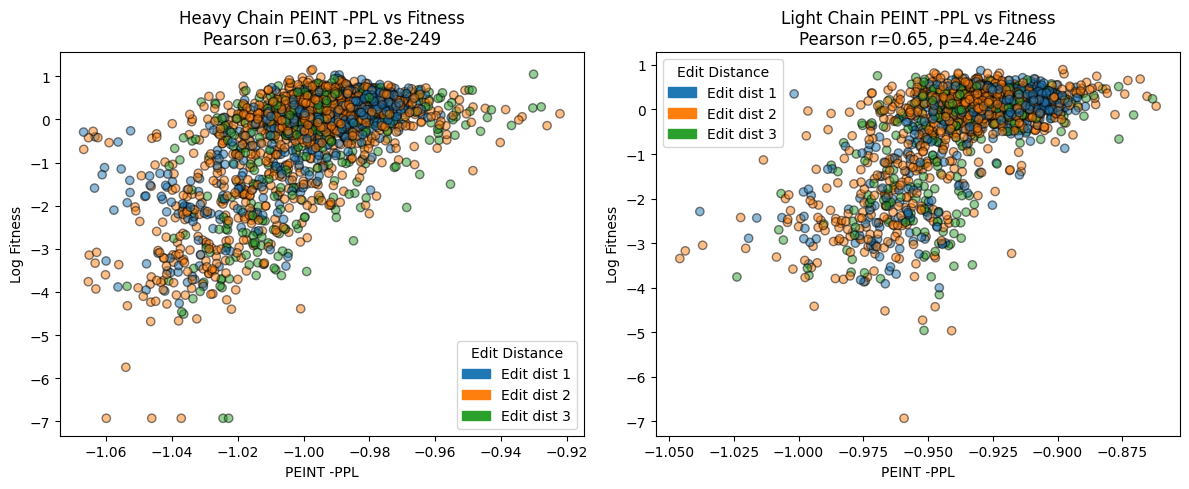

In [ ]:
NEUTRAL_MUTATION_CORRECTION = False

ppl_column = 'corrected_ppl' if NEUTRAL_MUTATION_CORRECTION else 'ppl'

import numpy as np
from scipy.stats import pearsonr
import matplotlib.patches as mpatches

# Calculate Pearson correlation for heavy and light chains
hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))

# plot ll vs fitness for heavy and light chains, colored by edit distance, and show Pearson r
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

if NEUTRAL_MUTATION_CORRECTION:
    unique_edits_hv = sorted(df_heavy['shm_edit_distance'].dropna().unique())
    cmap = plt.get_cmap('tab10')
    cdict_hv = {ed: cmap(i % 10) for i, ed in enumerate(unique_edits_hv)}
    colors_hv = df_heavy['shm_edit_distance'].map(cdict_hv)

    scatter_hv = ax[0].scatter(
        -df_heavy[ppl_column],
        np.log(df_heavy['fitness']),
        c=colors_hv,
        edgecolor='black',
        alpha=0.5
    )
    handles_hv = [
        mpatches.Patch(color=cdict_hv[ed], label=f'Edit dist {int(ed)}')
        for ed in unique_edits_hv
    ]
    ax[0].legend(handles=handles_hv, title="Edit Distance")

    unique_edits_lt = sorted(df_light['shm_edit_distance'].dropna().unique())
    cdict_lt = {ed: cmap(i % 10) for i, ed in enumerate(unique_edits_lt)}
    colors_lt = df_light['shm_edit_distance'].map(cdict_lt)

    scatter_lt = ax[1].scatter(
        -df_light[ppl_column],
        np.log(df_light['fitness']),
        c=colors_lt,
        edgecolor='black',
        alpha=0.5
    )
    handles_lt = [
        mpatches.Patch(color=cdict_lt[ed], label=f'Edit dist {int(ed)}')
        for ed in unique_edits_lt
    ]
    ax[1].legend(handles=handles_lt, title="Edit Distance")
else:
    ax[0].scatter(-df_heavy[ppl_column], np.log(df_heavy['fitness']), edgecolor='black', alpha=0.5)
    ax[1].scatter(-df_light[ppl_column], np.log(df_light['fitness']), edgecolor='black', alpha=0.5)

ax[0].set_title(f'Heavy Chain PEINT -PPL vs Fitness\nPearson r={hv_corr:.2f}, p={hv_pval:.2g}')
ax[0].set_xlabel('PEINT -PPL')
ax[0].set_ylabel('Log Fitness')

ax[1].set_title(f'Light Chain PEINT -PPL vs Fitness\nPearson r={lt_corr:.2f}, p={lt_pval:.2g}')
ax[1].set_xlabel('PEINT -PPL')
ax[1].set_ylabel('Log Fitness')

plt.tight_layout()
plt.show()